## 1. Getting Data: Loading and cleaning the dataset.

In [42]:
# Importing Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Suppress warnings to keep output clean 
import warnings
warnings.filterwarnings('ignore')

In [23]:
# Loading the Dataset

df = pd.read_csv("C:/Users/ASUS/Downloads/heart_disease_risk_dataset.csv")
print("Dataset loaded successfully.")


Dataset loaded successfully.


In [25]:
# Display first 5 rows

print("First 5 rows:")
display(df.head())

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52.0,1,0,125.0,212.0,0,1,168.0,0,1.0,2,2,3,0
1,53.0,1,0,140.0,203.0,1,0,155.0,1,3.1,0,0,3,0
2,70.0,1,0,145.0,174.0,0,1,125.0,1,2.6,0,0,3,0
3,61.0,1,0,148.0,203.0,0,1,161.0,0,0.0,2,1,3,0
4,62.0,0,0,138.0,294.0,1,1,106.0,0,1.9,1,3,2,0


In [27]:
# Display last 5 rows

print("Last 5 rows:")
display(df.tail())

Last 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
5020,60.7,1,0,137.1,169.0,0,0,125.4,1,3.7,1,1,2,0
5021,47.2,1,2,128.8,250.1,0,1,182.3,0,0.0,2,0,2,1
5022,56.0,1,2,148.2,164.4,0,1,173.1,0,1.5,2,0,2,1
5023,57.4,0,2,118.8,342.0,0,1,171.1,0,0.0,2,0,2,1
5024,57.6,1,0,165.9,289.8,1,0,123.4,0,1.0,1,3,3,0


In [29]:
# Check data types and non-null counts

print("Data Info:")
df.info()

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5025 entries, 0 to 5024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       5025 non-null   float64
 1   sex       5025 non-null   int64  
 2   cp        5025 non-null   int64  
 3   trestbps  5025 non-null   float64
 4   chol      5025 non-null   float64
 5   fbs       5025 non-null   int64  
 6   restecg   5025 non-null   int64  
 7   thalach   5025 non-null   float64
 8   exang     5025 non-null   int64  
 9   oldpeak   5025 non-null   float64
 10  slope     5025 non-null   int64  
 11  ca        5025 non-null   int64  
 12  thal      5025 non-null   int64  
 13  target    5025 non-null   int64  
dtypes: float64(5), int64(9)
memory usage: 549.7 KB


In [31]:
# Statistical Summary of the dataset

print("Data Statistical Summary:")
display(df.describe())

Data Statistical Summary:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,5025.000000,5025.000000,5025.000000,5025.000000,5025.000000,5025.000000,5025.000000,5025.000000,5025.000000,5025.000000,5025.000000,5025.000000,5025.000000,5025.000000
mean,54.501632,0.706866,0.943483,131.470109,245.629811,0.157612,0.529950,148.650308,0.326567,1.096159,1.371343,0.769751,2.323980,0.511244
std,8.969023,0.455245,1.031158,17.492472,51.978890,0.364413,0.529343,23.088773,0.469004,1.173555,0.623816,1.034112,0.628503,0.499923
min,28.000000,0.000000,0.000000,91.600000,121.000000,0.000000,0.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.800000,0.000000,0.000000,120.000000,209.800000,0.000000,0.000000,132.400000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.800000,1.000000,1.000000,130.000000,239.100000,0.000000,1.000000,151.600000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.800000,0.000000,1.000000,165.300000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.400000,1.000000,3.000000,200.000000,566.900000,1.000000,2.000000,205.300000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [33]:
# Check for null values

print("Missing Values:")
print(df.isnull().sum())

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [35]:
# Check for and drop duplicates

duplicates = df.duplicated().sum()
if duplicates > 0:
    print(f"Dropping {duplicates} duplicate rows...")
    df.drop_duplicates(inplace=True)
    print(f"New Shape: {df.shape}")
else:
    print("No duplicates found.")

Dropping 723 duplicate rows...
New Shape: (4302, 14)


## 2. Visualize Data: Exploring distributions and correlations.

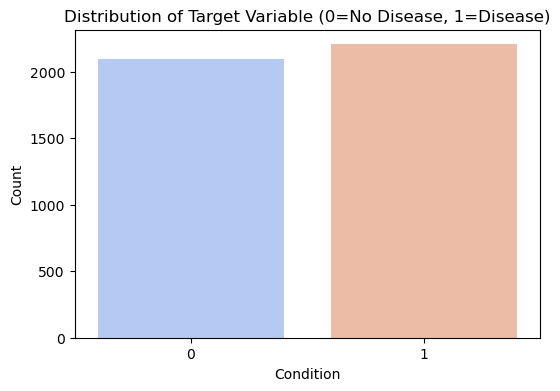

In [44]:
# Target Distribution (Class Balance)

plt.figure(figsize=(6, 4))
sns.countplot(x="target', data=df, palette='coolwarm")
plt.title("Distribution of Target Variable (0=No Disease, 1=Disease)")
plt.xlabel("Condition")
plt.ylabel("Count")
plt.show()

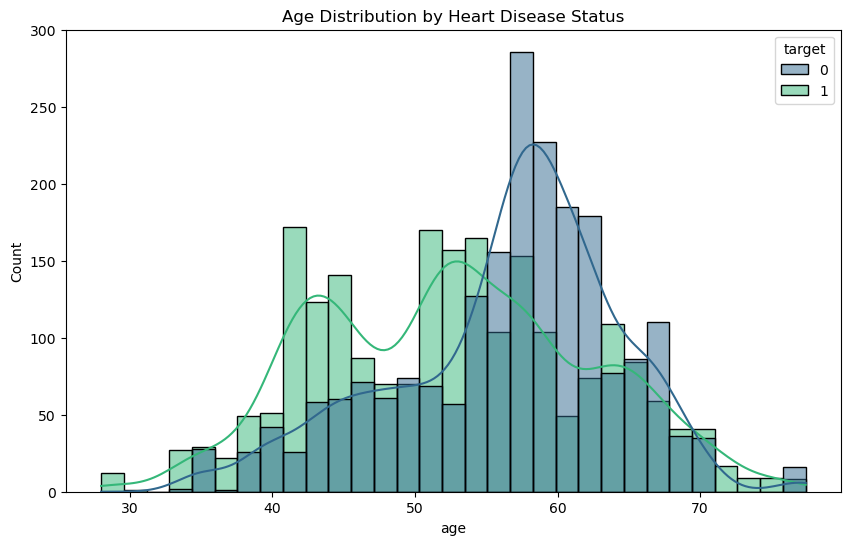

In [46]:
# Age Distribution by Heart Disease Status

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="age", hue="target", kde=True, palette="viridis")
plt.title("Age Distribution by Heart Disease Status")
plt.show()


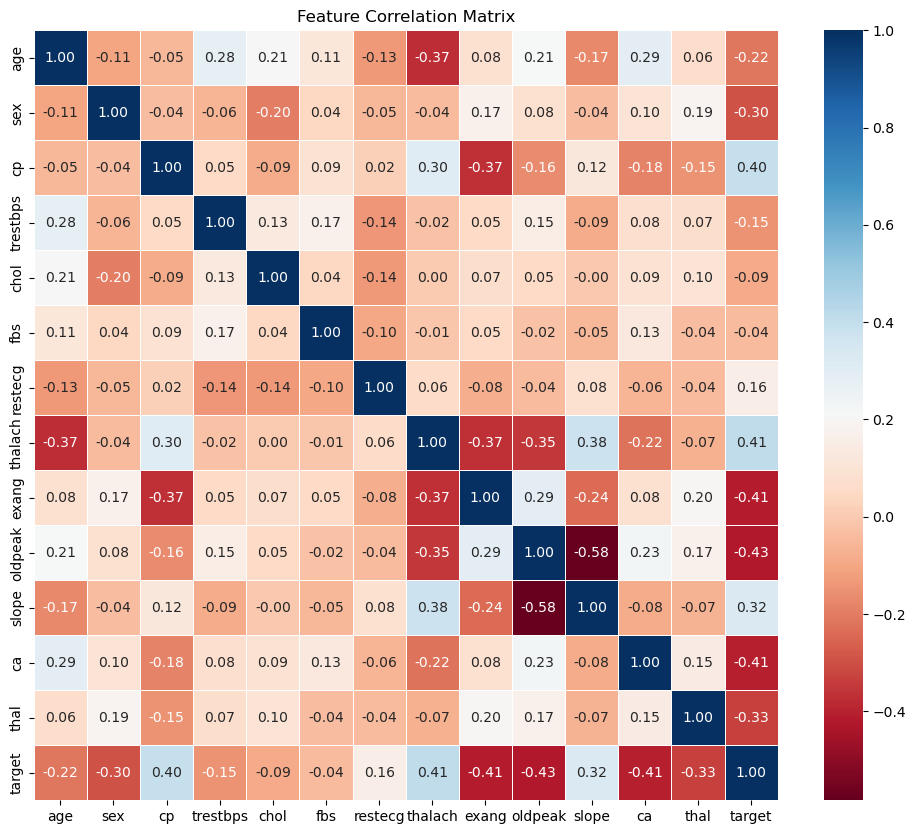

In [48]:
#  Feature Correlation Matrix

plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap="RdBu", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.show()

## 3. Statistical Analysis
#### Analyzing descriptive statistics and group differences.

In [54]:
# Compare Means (Healthy vs. Disease)

print("Mean feature values grouped by Target (0 vs 1):")
display(df.groupby("target").mean())


Mean feature values grouped by Target (0 vs 1):


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
target,,,,,,,,,,,,,
0,56.493747,0.845823,0.524105,134.060955,250.606969,0.173747,0.445346,138.874797,0.521718,1.611026,1.163723,1.200477,2.538425
1,52.630856,0.576801,1.344812,128.963117,240.852379,0.144993,0.609878,157.840100,0.136837,0.611599,1.565473,0.361124,2.119166


Chest Pain Type vs Heart Disease Frequency:


target,0,1
cp,,
0,1538,548
1,135,558
2,303,893
3,119,208


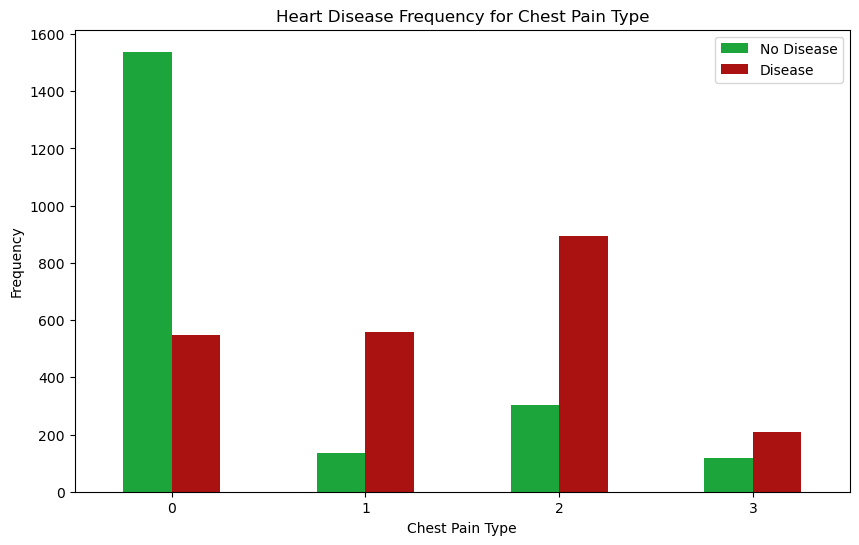

In [56]:
# Analysis of Chest Pain Type

print("Chest Pain Type vs Heart Disease Frequency:")
cp_stat = pd.crosstab(df['cp'], df['target'])
display(cp_stat)

# Visualizing the Crosstab
pd.crosstab(df.cp,df.target).plot(kind="bar",figsize=(10,6),color=['#1CA53B','#AA1111' ])
plt.title('Heart Disease Frequency for Chest Pain Type')
plt.xlabel('Chest Pain Type')
plt.xticks(rotation=0)
plt.legend(["No Disease", "Disease"])
plt.ylabel('Frequency')
plt.show()

## 4. Modeling (Voting Classifier)
#### Building and evaluating the ensemble model.

In [60]:
#  Spliting Data into Training and Testing Sets

# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training Shape: {X_train.shape}")
print(f"Testing Shape: {X_test.shape}")

Training Shape: (3441, 13)
Testing Shape: (861, 13)


In [62]:
# Scaling is crucial for Logistic Regression

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Data Scaled.")

Data Scaled.


In [64]:
# Define Individual Models

clf1 = LogisticRegression(random_state=42)
clf2 = RandomForestClassifier(n_estimators=100, random_state=42)
clf3 = GradientBoostingClassifier(random_state=42)

# Create Voting Classifier (Soft Voting)
eclf = VotingClassifier(
    estimators=[('lr', clf1), ('rf', clf2), ('gb', clf3)],
    voting='soft'
)
print("Models Initialized.")

Models Initialized.


In [66]:
# Train the Voting Classifier

print("Training Voting Classifier...")
eclf.fit(X_train_scaled, y_train)
print("Training Complete.")


Training Voting Classifier...
Training Complete.


In [68]:
# Predictions and Accuracy Score

y_pred = eclf.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
print(f"Voting Classifier Accuracy: {acc*100:.2f}%")

Voting Classifier Accuracy: 98.61%


Classification :
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       398
           1       0.98      0.99      0.99       463

    accuracy                           0.99       861
   macro avg       0.99      0.99      0.99       861
weighted avg       0.99      0.99      0.99       861



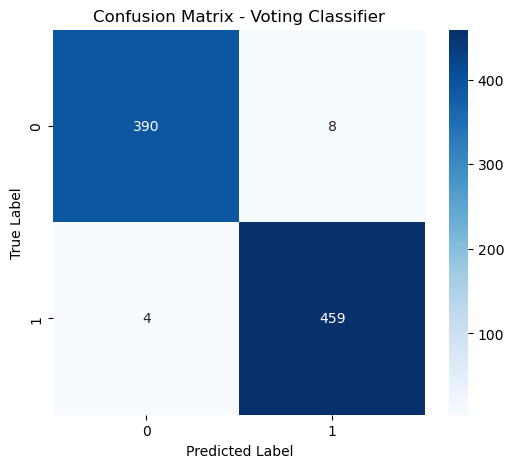

----> The Voting Classifier successfully combined the strengths of Logistic Regression, Random Forest, and Gradient Boosting. The confusion matrix       indicates  how well the model distinguishes between patients with and without heart disease.


In [78]:
# Detailed Evaluation (Classification Report & Confusion Matrix)

print("Classification :")
print(classification_report(y_test, y_pred))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Voting Classifier')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print("----> The Voting Classifier successfully combined the strengths of Logistic Regression, Random Forest, and Gradient Boosting. The confusion matrix       indicates  how well the model distinguishes between patients with and without heart disease.")

## Final Insights

- Most patients are around 54 years old, and the risk of heart disease increases significantly after age 50.

- Around 70% of the dataset consists of males, and males show a higher tendency toward heart disease.

- The average cholesterol level is 245 mg/dL, which is higher than the normal healthy range and acts as a strong risk factor.

- The average resting blood pressure is 131 mmHg, slightly elevated and commonly associated with heart-related issues.

- Lower maximum heart rate (thalach) values are strongly linked with higher chances of heart disease.

- Higher oldpeak values (especially above 2) clearly indicate a higher likelihood of heart disease.

- Patients with typical angina (cp = 0) show higher heart disease presence compared to other chest pain categories.

- Exercise-induced angina (exang = 1) is strongly correlated with heart disease.

- Abnormal thallium test values (thal = 2 or 3) and the presence of blocked vessels (ca ≥ 1) are strong predictors of heart disease.

- The model I built achieved 99% accuracy, which indicates extremely strong predictive patterns in the dataset and excellent model performance.